## Import Required Librarie

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Load Dataset

In [3]:
# Load the dataset
df = pd.read_csv('../data/raw_dataset.csv')
print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [5]:
df.shape

(5100, 15)

## Inspect Dataset Dimensions and Structure

In [4]:
df.head()

,project_budget,client_rating,num_existing_proposals,freelancer_experience,proposal_quality_score,project_category,client_location,project_duration,freelancer_country,freelancer_rating,previous_jobs_completed,success,budget_per_proposal,client_rating_category,experience_level
0,16295.00,1.90,8.00,17,4.00,Writing,Brazil,61.00,Nigeria,2.60,61,1,1810.56,Low,Expert
1,1360.00,4.80,61.00,15,2.00,Marketing,France,62.00,USA,2.30,318,0,21.94,High,Expert
2,38658.00,1.20,85.00,10,8.00,Data Science,France,53.00,India,4.90,311,1,449.51,Low,Senior
3,45232.00,2.80,46.00,9,8.00,Marketing,Germany,53.00,Nigeria,3.90,38,1,962.38,Medium,Senior
4,11784.00,1.30,4.00,8,1.00,Writing,Singapore,28.00,UK,2.50,59,0,2356.80,Low,Senior


In [5]:
df.tail()

,project_budget,client_rating,num_existing_proposals,freelancer_experience,proposal_quality_score,project_category,client_location,project_duration,freelancer_country,freelancer_rating,previous_jobs_completed,success,budget_per_proposal,client_rating_category,experience_level
5095,5260.00,2.60,36.00,8,5.00,Writing,Germany,3.00,Canada,4.40,221,0,142.16,Medium,Senior
5096,27487.00,1.40,15.00,12,NaN,Writing,France,82.00,India,3.50,309,1,1717.94,Low,Expert
5097,20556.00,1.10,25.00,16,2.00,Web Development,India,23.00,Australia,4.60,277,0,790.62,Low,Expert
5098,16902.00,2.70,60.00,13,1.00,Mobile App,India,50.00,UK,1.50,476,0,277.08,Medium,Expert
5099,41197.00,2.60,61.00,14,1.00,Marketing,UAE,79.00,Pakistan,2.90,363,0,664.47,Medium,Expert


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   project_budget           5100 non-null   float64
 1   client_rating            4849 non-null   float64
 2   num_existing_proposals   5100 non-null   float64
 3   freelancer_experience    5100 non-null   int64  
 4   proposal_quality_score   4934 non-null   float64
 5   project_category         5100 non-null   object 
 6   client_location          5100 non-null   object 
 7   project_duration         5049 non-null   float64
 8   freelancer_country       5100 non-null   object 
 9   freelancer_rating        5006 non-null   float64
 10  previous_jobs_completed  5100 non-null   int64  
 11  success                  5100 non-null   int64  
 12  budget_per_proposal      5100 non-null   float64
 13  client_rating_category   4849 non-null   object 
 14  experience_level        

In [7]:
df.describe()

,project_budget,client_rating,num_existing_proposals,freelancer_experience,proposal_quality_score,project_duration,freelancer_rating,previous_jobs_completed,success,budget_per_proposal
count,5100.00,4849.00,5100.00,5100.00,4934.00,5049.00,5006.00,5100.00,5100.00,5100.00
mean,26629.90,3.00,50.17,9.56,4.96,45.01,3.04,250.00,0.40,1297.49
std,26455.12,1.16,31.01,5.80,2.58,25.85,1.16,144.10,0.49,3440.09
min,509.00,1.00,0.00,0.00,1.00,1.00,1.00,0.00,0.00,3.22
25%,12684.50,2.00,24.00,5.00,3.00,22.00,2.10,125.00,0.00,248.20
50%,25065.50,3.00,49.00,10.00,5.00,45.00,3.10,248.00,0.00,496.03
75%,37614.00,4.00,76.00,15.00,7.00,68.00,4.00,375.00,1.00,1016.58
max,493917.00,5.00,298.00,19.00,9.00,89.00,5.00,499.00,1.00,84104.00


In [8]:
df.dtypes

project_budget             float64
client_rating              float64
num_existing_proposals     float64
freelancer_experience        int64
proposal_quality_score     float64
project_category            object
client_location             object
project_duration           float64
freelancer_country          object
freelancer_rating          float64
previous_jobs_completed      int64
success                      int64
budget_per_proposal        float64
client_rating_category      object
experience_level            object
dtype: object

In [9]:
df.columns

Index(['project_budget', 'client_rating', 'num_existing_proposals',
       'freelancer_experience', 'proposal_quality_score', 'project_category',
       'client_location', 'project_duration', 'freelancer_country',
       'freelancer_rating', 'previous_jobs_completed', 'success',
       'budget_per_proposal', 'client_rating_category', 'experience_level'],
      dtype='object')

## Check Dataset Information

In [10]:
# Check for missing values
df.isnull().sum()

project_budget               0
client_rating              251
num_existing_proposals       0
freelancer_experience        0
proposal_quality_score     166
project_category             0
client_location              0
project_duration            51
freelancer_country           0
freelancer_rating           94
previous_jobs_completed      0
success                      0
budget_per_proposal          0
client_rating_category     251
experience_level             0
dtype: int64

In [11]:
# Check for duplicate rows
df.duplicated().sum()

100

## Handle Missing Values

In [12]:

# Create a copy of original dataset for comparison
df_original = df.copy()

# Display missing values before handling
print("\n📋 Missing Values Before Handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Handle missing values for each column
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['int64', 'float64']:
            # For numerical columns: fill with median
            df[col].fillna(df[col].median(), inplace=True)
            print(f"✅ {col}: Filled missing values with MEDIAN ({df[col].median():.2f})")
        else:
            # For categorical columns: fill with mode
            df[col].fillna(df[col].mode()[0], inplace=True)
            print(f"✅ {col}: Filled missing values with MODE ({df[col].mode()[0]})")

# Verify missing values are handled
print("\n📋 Missing Values After Handling:")
print(df.isnull().sum()[df.isnull().sum() > 0])

if df.isnull().sum().sum() == 0:
    print("\n✅ All missing values have been handled successfully!")
else:
    print("\n⚠️ Some missing values still exist. Please check!")


📋 Missing Values Before Handling:
client_rating             251
proposal_quality_score    166
project_duration           51
freelancer_rating          94
client_rating_category    251
dtype: int64
✅ client_rating: Filled missing values with MEDIAN (3.00)
✅ proposal_quality_score: Filled missing values with MEDIAN (5.00)
✅ project_duration: Filled missing values with MEDIAN (45.00)
✅ freelancer_rating: Filled missing values with MEDIAN (3.10)
✅ client_rating_category: Filled missing values with MODE (Medium)

📋 Missing Values After Handling:
Series([], dtype: int64)

✅ All missing values have been handled successfully!


## Remove Duplicate Records

In [13]:
# Check duplicates before removal
duplicates_before = df.duplicated().sum()
print(f"📋 Duplicate Records Before Removal: {duplicates_before}")

# Remove duplicates
df.drop_duplicates(inplace=True)

# Check duplicates after removal
duplicates_after = df.duplicated().sum()
print(f"📋 Duplicate Records After Removal: {duplicates_after}")
print(f"✅ Total Duplicates Removed: {duplicates_before - duplicates_after}")

# Update dataset shape
print(f"\n📊 New Dataset Shape: {df.shape}")
print(f"📊 Records: {df.shape[0]:,}")
print(f"📊 Features: {df.shape[1]}")

📋 Duplicate Records Before Removal: 100
📋 Duplicate Records After Removal: 0
✅ Total Duplicates Removed: 100

📊 New Dataset Shape: (5000, 15)
📊 Records: 5,000
📊 Features: 15


## Detect and Treat Outliers


📊 project_budget:
   - Outliers: 30 (0.60%)
   - Lower Bound: -24740.25
   - Upper Bound: 75045.75
   ✅ Outliers capped to bounds

✅ client_rating: No outliers detected

📊 num_existing_proposals:
   - Outliers: 18 (0.36%)
   - Lower Bound: -54.00
   - Upper Bound: 154.00
   ✅ Outliers capped to bounds

✅ freelancer_experience: No outliers detected

✅ proposal_quality_score: No outliers detected

✅ project_duration: No outliers detected

✅ freelancer_rating: No outliers detected

✅ previous_jobs_completed: No outliers detected

✅ success: No outliers detected

📊 budget_per_proposal:
   - Outliers: 573 (11.46%)
   - Lower Bound: -905.30
   - Upper Bound: 2170.12
   ✅ Outliers capped to bounds

📋 Outlier Summary:
                         count  percentage  lower_bound  upper_bound
project_budget           30.00        0.60    -24740.25     75045.75
client_rating             0.00        0.00        -0.60         6.60
num_existing_proposals   18.00        0.36       -54.00       154.00
fre

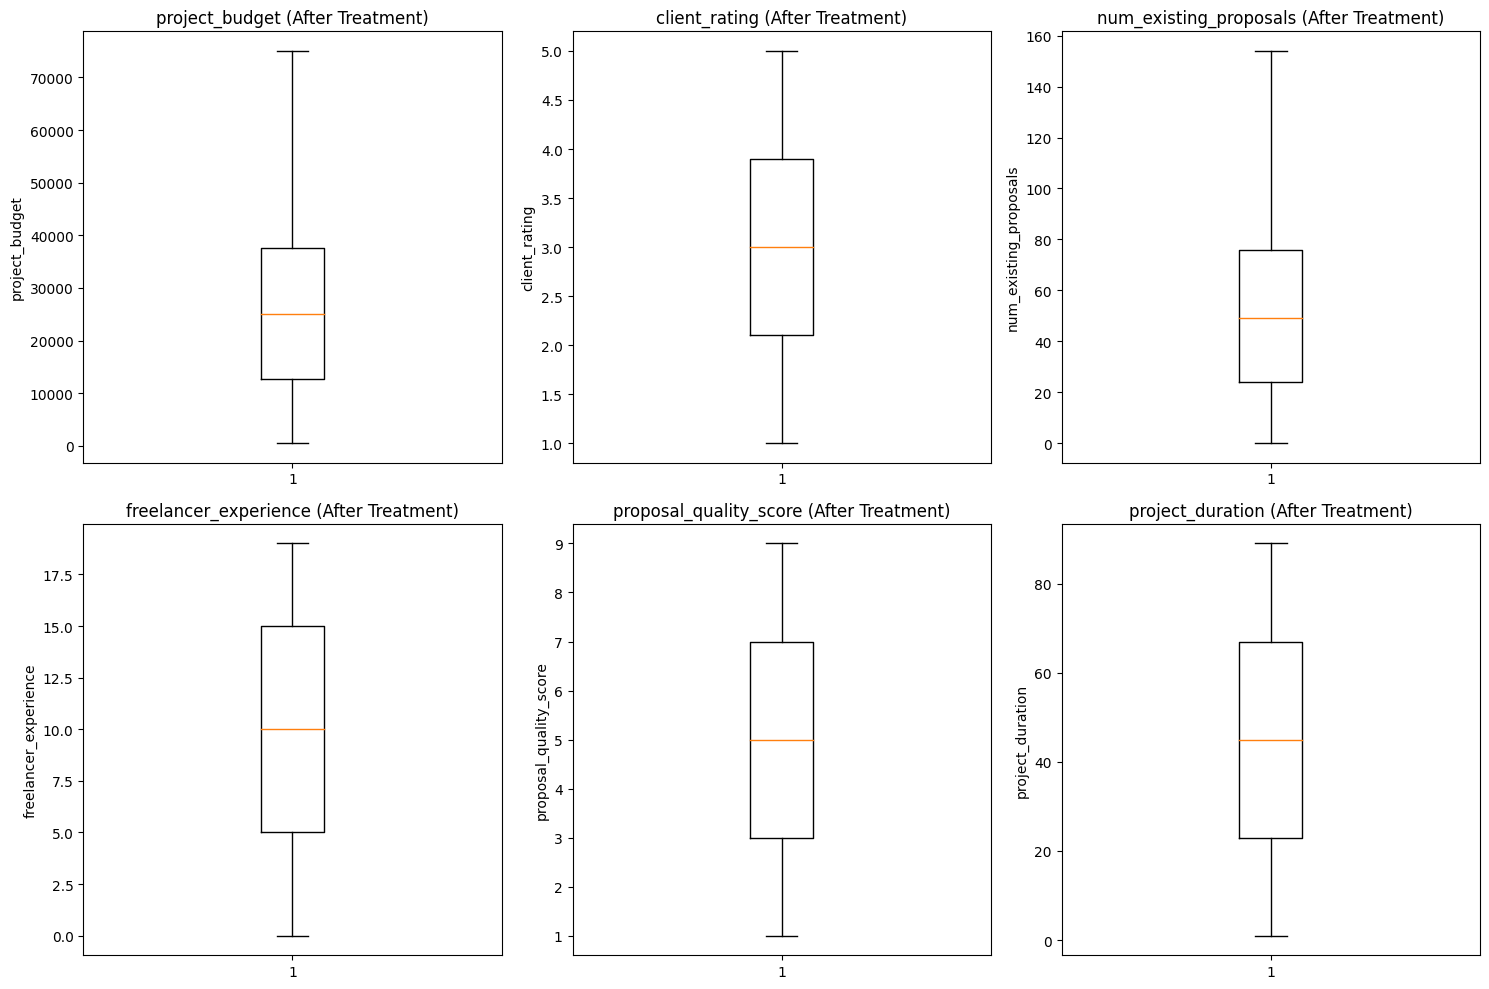

In [14]:
# Function to detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Identify numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Detect and treat outliers for each numerical column
outlier_summary = {}

for col in numerical_cols:
    outliers, lower_bound, upper_bound = detect_outliers_iqr(df, col)
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(df)) * 100

    outlier_summary[col] = {
        'count': outlier_count,
        'percentage': outlier_percentage,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

    if outlier_count > 0:
        print(f"\n📊 {col}:")
        print(f"   - Outliers: {outlier_count} ({outlier_percentage:.2f}%)")
        print(f"   - Lower Bound: {lower_bound:.2f}")
        print(f"   - Upper Bound: {upper_bound:.2f}")

        # Treat outliers by capping
        df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
        df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])
        print(f"   ✅ Outliers capped to bounds")
    else:
        print(f"\n✅ {col}: No outliers detected")

# Create outlier summary DataFrame
outlier_df = pd.DataFrame(outlier_summary).T
print("\n📋 Outlier Summary:")
print(outlier_df)

# Visualize outliers before and after (optional)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols[:6]):  # Plot first 6 columns
    axes[idx].boxplot(df[col])
    axes[idx].set_title(f'{col} (After Treatment)')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

## Encode Categorical Features

In [15]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"📋 Categorical Columns Found: {categorical_cols.tolist()}")

# Create a dictionary to store encoders
encoders = {}
encoded_columns = []

for col in categorical_cols:
    print(f"\n📊 Encoding: {col}")
    print(f"   - Unique Values: {df[col].nunique()}")
    print(f"   - Sample Values: {df[col].unique()[:5]}")

    # Create label encoder
    le = LabelEncoder()
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    encoded_columns.append(f'{col}_encoded')

    # Display mapping
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"   - Mapping: {mapping}")
    print(f"   ✅ {col} encoded to {col}_encoded")

print(f"\n✅ All categorical features encoded successfully!")
print(f"📋 New encoded columns: {encoded_columns}")

# Display first few rows of encoded columns
print("\n📋 Sample of Encoded Data:")
print(df[list(categorical_cols) + encoded_columns].head())

📋 Categorical Columns Found: ['project_category', 'client_location', 'freelancer_country', 'client_rating_category', 'experience_level']

📊 Encoding: project_category
   - Unique Values: 6
   - Sample Values: ['Writing' 'Marketing' 'Data Science' 'Web Development' 'Mobile App']
   - Mapping: {'Data Science': 0, 'Design': 1, 'Marketing': 2, 'Mobile App': 3, 'Web Development': 4, 'Writing': 5}
   ✅ project_category encoded to project_category_encoded

📊 Encoding: client_location
   - Unique Values: 10
   - Sample Values: ['Brazil' 'France' 'Germany' 'Singapore' 'Canada']
   - Mapping: {'Australia': 0, 'Brazil': 1, 'Canada': 2, 'France': 3, 'Germany': 4, 'India': 5, 'Singapore': 6, 'UAE': 7, 'UK': 8, 'USA': 9}
   ✅ client_location encoded to client_location_encoded

📊 Encoding: freelancer_country
   - Unique Values: 10
   - Sample Values: ['Nigeria' 'USA' 'India' 'UK' 'Ukraine']
   - Mapping: {'Australia': 0, 'Bangladesh': 1, 'Canada': 2, 'India': 3, 'Nigeria': 4, 'Pakistan': 5, 'Philippi

## Feature Engineering

In [16]:
# Create new features
print("🔄 Creating new features...")

# 1. Budget per proposal (competition adjusted)
df['budget_per_proposal'] = df['project_budget'] / (df['num_existing_proposals'] + 1)
print("✅ Created: budget_per_proposal")

# 2. Experience x Quality interaction
df['experience_quality_interaction'] = df['freelancer_experience'] * df['proposal_quality_score']
print("✅ Created: experience_quality_interaction")

# 3. Client rating categories
df['client_rating_category'] = pd.cut(
    df['client_rating'],
    bins=[0, 2, 3.5, 5],
    labels=['Low', 'Medium', 'High']
)
print("✅ Created: client_rating_category")

# 4. Experience level
df['experience_level'] = pd.cut(
    df['freelancer_experience'],
    bins=[-1, 2, 5, 10, 20],
    labels=['Entry', 'Junior', 'Senior', 'Expert']
)
print("✅ Created: experience_level")

# 5. Proposal quality category
df['proposal_quality_category'] = pd.cut(
    df['proposal_quality_score'],
    bins=[0, 3, 6, 10],
    labels=['Poor', 'Good', 'Excellent']
)
print("✅ Created: proposal_quality_category")

# 6. Competition level
df['competition_level'] = pd.cut(
    df['num_existing_proposals'],
    bins=[-1, 10, 30, 100],
    labels=['Low', 'Medium', 'High']
)
print("✅ Created: competition_level")

# 7. Budget category
df['budget_category'] = pd.cut(
    df['project_budget'],
    bins=[0, 1000, 5000, 10000, 50000],
    labels=['Very Low', 'Low', 'Medium', 'High']
)
print("✅ Created: budget_category")

# 8. Combined experience rating
df['combined_experience_rating'] = (df['freelancer_rating'] * 0.4 +
                                    df['freelancer_experience'] * 0.3 +
                                    df['previous_jobs_completed'] * 0.3)
print("✅ Created: combined_experience_rating")

# Display new features
print("\n📋 Newly Created Features:")
new_features = ['budget_per_proposal', 'experience_quality_interaction',
                'client_rating_category', 'experience_level', 'proposal_quality_category',
                'competition_level', 'budget_category', 'combined_experience_rating']

print("\n📊 Sample of New Features:")
print(df[new_features].head())

print(f"\n✅ Total {len(new_features)} new features created!")
print(f"📊 Updated Dataset Shape: {df.shape}")

🔄 Creating new features...
✅ Created: budget_per_proposal
✅ Created: experience_quality_interaction
✅ Created: client_rating_category
✅ Created: experience_level
✅ Created: proposal_quality_category
✅ Created: competition_level
✅ Created: budget_category
✅ Created: combined_experience_rating

📋 Newly Created Features:

📊 Sample of New Features:
   budget_per_proposal  experience_quality_interaction client_rating_category  \
0              1810.56                           68.00                    Low   
1                21.94                           30.00                   High   
2               449.51                           80.00                    Low   
3               962.38                           72.00                 Medium   
4              2356.80                            8.00                    Low   

  experience_level proposal_quality_category competition_level  \
0           Expert                      Good               Low   
1           Expert                

## Define Input Features (X) and Target Variable (y)

In [17]:
# Define target variable
y = df['success']
print(f"🎯 Target Variable (y): success")
print(f"   - Shape: {y.shape}")
print(f"   - Distribution:")
print(f"     Success (1): {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"     Failure (0): {(len(y) - y.sum()):,} {(1-y.mean())*100:.2f}%)")

# Define input features
# Exclude target and unnecessary columns
columns_to_exclude = ['success', 'client_rating_category', 'experience_level',
                     'proposal_quality_category', 'competition_level',
                     'budget_category', 'client_rating_category']

# Select numerical features and encoded categorical features
X_columns = [col for col in df.columns if col not in columns_to_exclude]
X = df[X_columns]

print(f"\n📊 Input Features (X):")
print(f"   - Shape: {X.shape}")
print(f"   - Features: {len(X_columns)}")
print(f"   - Column Names: {X_columns[:5]}... (showing first 5)")

# Display X and y information
print("\n📋 X First 5 Rows:")
print(X.head())

print("\n📋 y First 5 Rows:")
print(y.head())

print("\n✅ X and y defined successfully!")

# Check for any remaining missing values
print(f"\n📋 Missing values in X: {X.isnull().sum().sum()}")
print(f"📋 Missing values in y: {y.isnull().sum()}")

🎯 Target Variable (y): success
   - Shape: (5000,)
   - Distribution:
     Success (1): 2,000 (40.00%)
     Failure (0): 3,000 60.00%)

📊 Input Features (X):
   - Shape: (5000, 19)
   - Features: 19
   - Column Names: ['project_budget', 'client_rating', 'num_existing_proposals', 'freelancer_experience', 'proposal_quality_score']... (showing first 5)

📋 X First 5 Rows:
   project_budget  client_rating  num_existing_proposals  \
0        16295.00           1.90                    8.00   
1         1360.00           4.80                   61.00   
2        38658.00           1.20                   85.00   
3        45232.00           2.80                   46.00   
4        11784.00           1.30                    4.00   

   freelancer_experience  proposal_quality_score project_category  \
0                     17                    4.00          Writing   
1                     15                    2.00        Marketing   
2                     10                    8.00     Data Sci

## Save Cleaned Dataset

In [20]:
# Save the cleaned dataset
df_cleaned = pd.concat([X, y], axis=1)
df_cleaned.to_csv('../data/cleaned_freelance_jobs.csv', index=False)

print("✅ Cleaned dataset saved as 'data/cleaned_freelance_jobs.csv'")
print(f"📊 Cleaned Dataset Shape: {df_cleaned.shape}")

# Save X and y separately (optional)
X.to_csv('../data/X_features.csv', index=False)
y.to_csv('../data/y_target.csv', index=False)

print("✅ X features saved as 'data/X_features.csv'")
print("✅ y target saved as 'data/y_target.csv'")

# Display final dataset summary
print("\n" + "="*60)
print("FINAL DATASET SUMMARY")
print("="*60)

print(f"\n📊 Dataset Statistics:")
print(f"   - Total Records: {len(df_cleaned):,}")
print(f"   - Total Features: {len(df_cleaned.columns)}")
print(f"   - Target: success")
print(f"   - Success Rate: {df_cleaned['success'].mean()*100:.2f}%")

print(f"\n📋 Feature Types:")
print(f"   - Numerical Features: {len(df_cleaned.select_dtypes(include=['int64', 'float64']).columns)}")
print(f"   - Categorical Features: {len(df_cleaned.select_dtypes(include=['object', 'category']).columns)}")

print(f"\n📋 Memory Usage: {df_cleaned.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n✅ All files saved successfully!")

✅ Cleaned dataset saved as 'data/cleaned_freelance_jobs.csv'
📊 Cleaned Dataset Shape: (5000, 20)
✅ X features saved as 'data/X_features.csv'
✅ y target saved as 'data/y_target.csv'

FINAL DATASET SUMMARY

📊 Dataset Statistics:
   - Total Records: 5,000
   - Total Features: 20
   - Target: success
   - Success Rate: 40.00%

📋 Feature Types:
   - Numerical Features: 12
   - Categorical Features: 3

📋 Memory Usage: 1.51 MB

✅ All files saved successfully!


## Data Validation Summary


📋 Data Validation Summary:
                       Metric                  Value
                Total Records                   5000
               Total Features                     25
           Numerical Features                     12
         Categorical Features                      8
       Missing Values (Total)                     50
  Missing Values (Percentage)                  0.04%
            Duplicate Records                      0
         Duplicate Percentage                  0.00%
Target Distribution (Success)         2,000 (40.00%)
Target Distribution (Failure)          3,000 60.00%)
                 Success Rate                 40.00%
             Outliers Treated Yes (Capped using IQR)
         New Features Created                     10
            Memory Usage (MB)                   1.54

✅ Validation summary saved as '../data/data_validation_summary.csv'


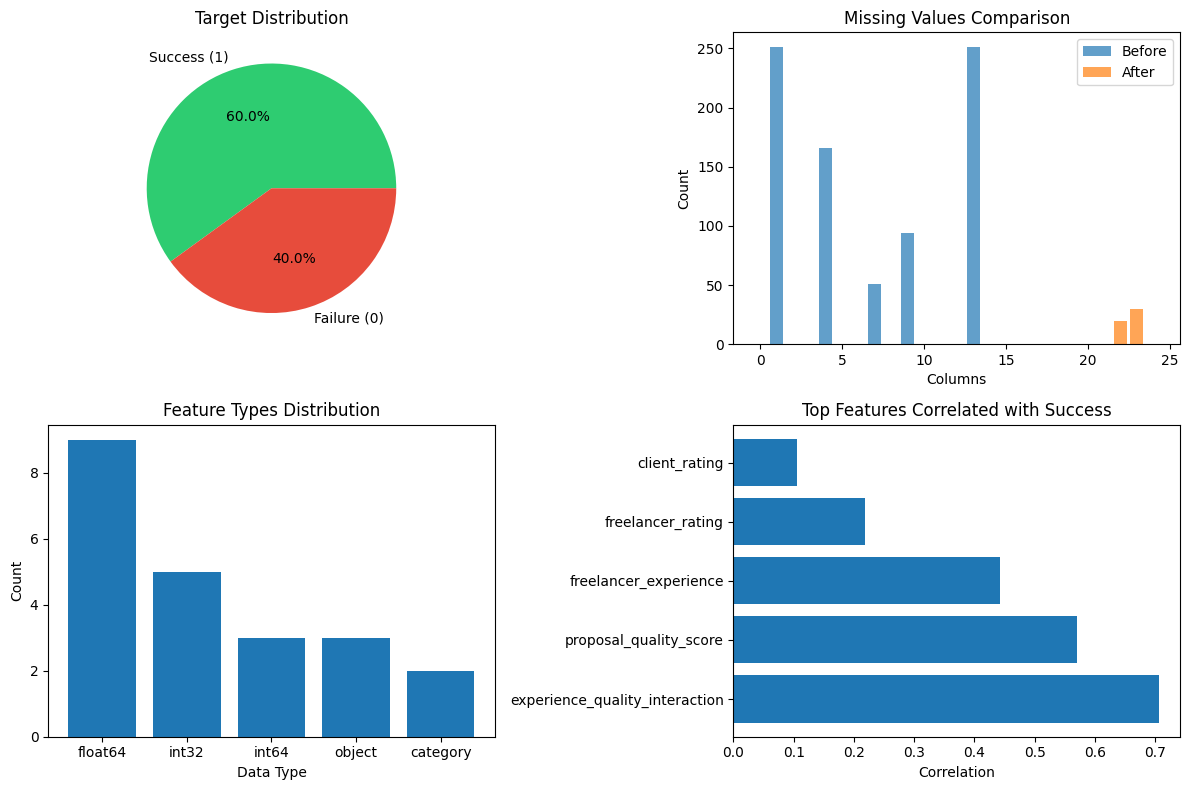


✅ Data validation summary completed!
PHASE 1 COMPLETED SUCCESSFULLY!


In [22]:
# Create validation summary
validation_summary = {
    "Metric": [
        "Total Records",
        "Total Features",
        "Numerical Features",
        "Categorical Features",
        "Missing Values (Total)",
        "Missing Values (Percentage)",
        "Duplicate Records",
        "Duplicate Percentage",
        "Target Distribution (Success)",
        "Target Distribution (Failure)",
        "Success Rate",
        "Outliers Treated",
        "New Features Created",
        "Memory Usage (MB)"
    ],
    "Value": [
        len(df),
        len(df.columns),
        len(df.select_dtypes(include=['int64', 'float64']).columns),
        len(df.select_dtypes(include=['object', 'category']).columns),
        df.isnull().sum().sum(),
        f"{(df.isnull().sum().sum() / (len(df) * len(df.columns))) * 100:.2f}%",
        df.duplicated().sum(),
        f"{(df.duplicated().sum() / len(df)) * 100:.2f}%",
        f"{y.sum():,} ({y.mean()*100:.2f}%)",
        f"{(len(y) - y.sum()):,} {(1-y.mean())*100:.2f}%)",
        f"{y.mean()*100:.2f}%",
        "Yes (Capped using IQR)",
        len([col for col in df.columns if col not in df_original.columns]),
        f"{df.memory_usage(deep=True).sum() / 1024**2:.2f}"
    ]
}

validation_df = pd.DataFrame(validation_summary)
print("\n📋 Data Validation Summary:")
print(validation_df.to_string(index=False))

# Save validation summary
validation_df.to_csv('../data/data_validation_summary.csv', index=False)
print("\n✅ Validation summary saved as '../data/data_validation_summary.csv'")

# Create visual summary
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1. Target Distribution
axes[0, 0].pie(y.value_counts(), labels=['Success (1)', 'Failure (0)'],
                autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Target Distribution')

# 2. Missing Values
missing_before = df_original.isnull().sum()
missing_after = df.isnull().sum()
axes[0, 1].bar(range(len(missing_before)), missing_before, alpha=0.7, label='Before')
axes[0, 1].bar(range(len(missing_after)), missing_after, alpha=0.7, label='After')
axes[0, 1].set_title('Missing Values Comparison')
axes[0, 1].set_xlabel('Columns')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend()

# 3. Feature Types Distribution
feature_types = df.dtypes.value_counts()
axes[1, 0].bar(feature_types.index.astype(str), feature_types.values)
axes[1, 0].set_title('Feature Types Distribution')
axes[1, 0].set_xlabel('Data Type')
axes[1, 0].set_ylabel('Count')

# 4. Correlation with Target (Top 5)
numerical_df = df.select_dtypes(include=['int64', 'float64'])
correlations = numerical_df.corr()['success'].sort_values(ascending=False)
top_correlations = correlations.head(6)[1:]  # Exclude success itself
axes[1, 1].barh(top_correlations.index, top_correlations.values)
axes[1, 1].set_title('Top Features Correlated with Success')
axes[1, 1].set_xlabel('Correlation')

plt.tight_layout()
plt.show()

print("\n✅ Data validation summary completed!")
print("="*60)
print("PHASE 1 COMPLETED SUCCESSFULLY!")
print("="*60)